In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append("/home/z5297792/UNSW-MRes/MRes/modules") 
from utils import dopioe, unit_det, fit_psi_params, psi_params, ellipse_aspect_ratio, axis_ratio_from_Q, espra

import re
def extract_number(s):
    match = re.search(r'\d+', s)
    return int(match.group()) if match else None


In [2]:
# def doppio(
#     x1, y1, u1, v1, x2, y2, u2, v2,
#     degree=3, tol=1e-8, plot=False,
#     use_A0=True, use_B0=True, use_C0=True, use_D0=True, use_D1=True
# ):
#     from scipy.optimize import least_squares

#     x1, y1, u1, v1 = map(lambda a: np.asarray(a, float), (x1, y1, u1, v1))
#     x2, y2, u2, v2 = map(lambda a: np.asarray(a, float), (x2, y2, u2, v2))

#     m1 = np.isfinite(x1) & np.isfinite(y1) & np.isfinite(u1) & np.isfinite(v1)
#     m2 = np.isfinite(x2) & np.isfinite(y2) & np.isfinite(u2) & np.isfinite(v2)
#     x1, y1, u1, v1 = x1[m1], y1[m1], u1[m1], v1[m1]
#     x2, y2, u2, v2 = x2[m2], y2[m2], u2[m2], v2[m2]

#     nan2 = np.full((2, 2), np.nan)
#     fail = (np.nan, np.nan, np.nan, nan2, np.nan, np.nan, np.nan, np.nan, np.nan)

#     if x1.size < degree + 1 or x2.size < degree + 1:
#         return fail

#     # intersection of transects
#     P1 = np.c_[x1, y1]
#     P2 = np.c_[x2, y2]
#     d2 = ((P1[:, None, :] - P2[None, :, :])**2).sum(-1)
#     i, j = np.unravel_index(np.argmin(d2), d2.shape)
#     if d2[i, j] > tol**2:
#         return fail

#     cx, cy = P1[i]
#     xx = x1 - cx
#     yy = y2 - cy

#     pu1 = np.polyfit(xx, u1, 3)  # [A3,A2,A1,A0] about xx=0
#     pv1 = np.polyfit(xx, v1, 3)  # [B3,B2,B1,B0]
#     pu2 = np.polyfit(yy, u2, 3)  # [C3,C2,C1,C0]
#     pv2 = np.polyfit(yy, v2, 3)  # [D3,D2,D1,D0]

#     # dynamic parameter vector
#     names = ["x0", "y0", "A1", "B1", "C1", "A2", "A3", "B2", "B3", "C2", "C3", "D2", "D3"]
#     p0 = [0.0, 0.0, pu1[2], pv1[2], pu2[2], pu1[1], pu1[0], pv1[1], pv1[0], pu2[1], pu2[0], pv2[1], pv2[0]]

#     if not use_A0:
#         names += ["A0"]
#         p0 += [pu1[3]]
#     if not use_B0:
#         names += ["B0"]
#         p0 += [pv1[3]]
#     if not use_C0:
#         names += ["C0"]
#         p0 += [pu2[3]]
#     if not use_D0:
#         names += ["D0"]
#         p0 += [pv2[3]]
#     if not use_D1:
#         names += ["D1"]
#         p0 += [pv2[2]]

#     name_to_idx = {n: k for k, n in enumerate(names)}

#     def get(p, name):
#         return p[name_to_idx[name]]

#     def residuals(p):
#         x0 = get(p, "x0")
#         y0 = get(p, "y0")
#         A1 = get(p, "A1")
#         B1 = get(p, "B1")
#         C1 = get(p, "C1")
#         A2 = get(p, "A2")
#         A3 = get(p, "A3")
#         B2 = get(p, "B2")
#         B3 = get(p, "B3")
#         C2 = get(p, "C2")
#         C3 = get(p, "C3")
#         D2 = get(p, "D2")
#         D3 = get(p, "D3")

#         A0 = -C1*y0 if use_A0 else get(p, "A0")
#         B0 =  A1*y0 if use_B0 else get(p, "B0")
#         C0 = -A1*x0 if use_C0 else get(p, "C0")
#         D0 = -B1*x0 if use_D0 else get(p, "D0")
#         D1 = -A1    if use_D1 else get(p, "D1")

#         dx = xx - x0
#         dy = yy - y0

#         U1 = A0 + A1*dx + A2*dx**2 + A3*dx**3
#         V1 = B0 + B1*dx + B2*dx**2 + B3*dx**3
#         U2 = C0 + C1*dy + C2*dy**2 + C3*dy**3
#         V2 = D0 + D1*dy + D2*dy**2 + D3*dy**3

#         s1 = np.nanstd(u1) or 1.0
#         s2 = np.nanstd(v1) or 1.0
#         s3 = np.nanstd(u2) or 1.0
#         s4 = np.nanstd(v2) or 1.0

#         return np.r_[(U1 - u1)/s1, (V1 - v1)/s2, (U2 - u2)/s3, (V2 - v2)/s4]

#     try:
#         res = least_squares(residuals, np.array(p0, float), method="trf")
#     except Exception:
#         return fail

#     p = res.x
#     x0 = get(p, "x0")
#     y0 = get(p, "y0")
#     A1 = get(p, "A1")
#     B1 = get(p, "B1")
#     C1 = get(p, "C1")
#     A2 = get(p, "A2")
#     A3 = get(p, "A3")
#     B2 = get(p, "B2")
#     B3 = get(p, "B3")
#     C2 = get(p, "C2")
#     C3 = get(p, "C3")
#     D2 = get(p, "D2")
#     D3 = get(p, "D3")

#     A0 = -C1*y0 if use_A0 else get(p, "A0")
#     B0 =  A1*y0 if use_B0 else get(p, "B0")
#     C0 = -A1*x0 if use_C0 else get(p, "C0")
#     D0 = -B1*x0 if use_D0 else get(p, "D0")
#     D1 = -A1    if use_D1 else get(p, "D1")

#     # derivative matrix at fitted closest-approach points

#     W = np.array([[A1, B1],
#                   [C1, D1]], float)

#     detW = np.linalg.det(W)
#     if not np.isfinite(detW) or detW <= 0:
#         return fail

#     Omega = np.sign(B1) * np.sqrt(detW)
#     if not np.isfinite(Omega) or Omega == 0:
#         return fail

#     J = np.array([[0.0, 1.0],
#                   [-1.0, 0.0]])

#     # keep your current sign convention
#     Q = -(J @ W) / Omega
#     # Q = 0.5 * (Q + Q.T)

#     detQ = np.linalg.det(Q)
#     if not np.isfinite(detQ) or detQ <= 0:
#         return fail
#     Q /= np.sqrt(detQ)

#     xc = cx + x0
#     yc = cy + y0
#     w = Omega * (Q[0, 0] + Q[1, 1])

#     dx1 = xx - x0
#     dy2 = yy - y0
#     U1 = A0 + A1*dx1 + A2*dx1**2 + A3*dx1**3
#     V1 = B0 + B1*dx1 + B2*dx1**2 + B3*dx1**3
#     U2 = C0 + C1*dy2 + C2*dy2**2 + C3*dy2**3
#     V2 = D0 + D1*dy2 + D2*dy2**2 + D3*dy2**3

#     if plot:
#         fig, axs = plt.subplots(2, 2, figsize=(8, 6))

#         xs = np.linspace(xx.min(), xx.max(), 200)
#         ys = np.linspace(yy.min(), yy.max(), 200)
#         dxs = xs - x0
#         dys = ys - y0

#         U1s = A0 + A1*dxs + A2*dxs**2 + A3*dxs**3
#         V1s = B0 + B1*dxs + B2*dxs**2 + B3*dxs**3
#         U2s = C0 + C1*dys + C2*dys**2 + C3*dys**3
#         V2s = D0 + D1*dys + D2*dys**2 + D3*dys**3

#         axs[0, 0].scatter(xx, u1, s=10)
#         axs[0, 0].plot(xs, U1s)
#         axs[0, 0].set_title("U1(x)")

#         axs[0, 1].scatter(xx, v1, s=10)
#         axs[0, 1].plot(xs, V1s)
#         axs[0, 1].set_title("V1(x)")

#         axs[1, 0].scatter(yy, u2, s=10)
#         axs[1, 0].plot(ys, U2s)
#         axs[1, 0].set_title("U2(y)")

#         axs[1, 1].scatter(yy, v2, s=10)
#         axs[1, 1].plot(ys, V2s)
#         axs[1, 1].set_title("V2(y)")

#         plt.tight_layout()
#         plt.show()

#     return xc, yc, w, Q, Omega, U1, V1, U2, V2


In [3]:
# def doppio(x1, y1, u1, v1, x2, y2, u2, v2):
#     x1, u1, v1 = map(lambda a: np.asarray(a, float), (x1, u1, v1))
#     y2, u2, v2 = map(lambda a: np.asarray(a, float), (y2, u2, v2))

#     m1 = np.isfinite(x1) & np.isfinite(u1) & np.isfinite(v1)
#     m2 = np.isfinite(y2) & np.isfinite(u2) & np.isfinite(v2)
#     x1, u1, v1 = x1[m1], u1[m1], v1[m1]
#     y2, u2, v2 = y2[m2], u2[m2], v2[m2]

#     x, y = x1, y2

#     # minimize the resiudal 
#     U1 = A0 + A1(x-x0) + A2(x-x0)**2 + A3(x-x0)**3
#     V1 = B0 + B1(x-x0) + B2(x-x0)**2 + B3(x-x0)**3

#     U2 = C0 + C1(y-y0) + C2(y-y0)**2 + C3(y-y0)**3
#     V2 = D0 + D1(y-y0) + D2(y-y0)**2 + D3(y-y0)**3

#     A0 = -C1*y0, B0 = -A1*y0, C0 = -A1*x0, D0=-B1*x0, A1 = -D1

#     # so
#     U1 = -C1*y0 + A1(x-x0) + A2(x-x0)**2 + A3(x-x0)**3
#     V1 = -A1*y0 + B1(x-x0) + B2(x-x0)**2 + B3(x-x0)**3

#     U2 = -A1*x0 + C1(y-y0) + C2(y-y0)**2 + C3(y-y0)**3
#     V2 = -B1*x0 + -A1(y-y0) + D2(y-y0)**2 + D3(y-y0)**3

#     # so find the indpendent variables x0, y0, A1, A2, A3, B1, B2, B3, C1, C2, C3, D2, D3
#     # by minimusing the residual abs(u1-U1) + abs(v1-V1) + abs(u2-U2) + abs(v2-V2) 

# def doppio(x1, y1, u1, v1, x2, y2, u2, v2, plot=False):
#     x1, u1, v1 = map(lambda a: np.asarray(a, float), (x1, u1, v1))
#     y2, u2, v2 = map(lambda a: np.asarray(a, float), (y2, u2, v2))

#     from scipy.optimize import least_squares

#     m1 = np.isfinite(x1) & np.isfinite(u1) & np.isfinite(v1)
#     m2 = np.isfinite(y2) & np.isfinite(u2) & np.isfinite(v2)
#     x1, u1, v1 = x1[m1], u1[m1], v1[m1]
#     y2, u2, v2 = y2[m2], u2[m2], v2[m2]

#     if len(x1) < 4 or len(y2) < 4:
#         raise ValueError("Need at least 4 finite points on each transect.")

#     x, y = x1, y2

#     def unpack(p):
#         x0, y0, A1, A2, A3, B1, B2, B3, C1, C2, C3, D2, D3 = p
#         return x0, y0, A1, A2, A3, B1, B2, B3, C1, C2, C3, D2, D3

#     def model(p):
#         x0, y0, A1, A2, A3, B1, B2, B3, C1, C2, C3, D2, D3 = unpack(p)

#         dx = x - x0
#         dy = y - y0

#         U1 = -C1 * y0 + A1 * dx + A2 * dx**2 + A3 * dx**3
#         V1 = -A1 * y0 + B1 * dx + B2 * dx**2 + B3 * dx**3

#         U2 = -A1 * x0 + C1 * dy + C2 * dy**2 + C3 * dy**3
#         V2 = -B1 * x0 - A1 * dy + D2 * dy**2 + D3 * dy**3

#         return U1, V1, U2, V2

#     def residuals(p):
#         U1, V1, U2, V2 = model(p)
#         return np.r_[u1 - U1, v1 - V1, u2 - U2, v2 - V2]

#     # x0_guess = np.nanmean(x)
#     x0_guess = x[np.argmin(np.abs(v1))]
#     # y0_guess = np.nanmean(y)
#     y0_guess = y[np.argmin(np.abs(u2))]

#     # linear guesses around mean-centered coordinates
#     dxg = x - x0_guess
#     dyg = y - y0_guess

#     def lin1(z, f):
#         if len(z) < 2:
#             return 0.0
#         p = np.polyfit(z, f, 1)
#         return p[0]

#     A1_guess = lin1(dxg, u1)
#     B1_guess = lin1(dxg, v1)
#     C1_guess = lin1(dyg, u2)

#     p0 = np.array([
#         x0_guess, y0_guess,
#         A1_guess, 0.0, 0.0,
#         B1_guess, 0.0, 0.0,
#         C1_guess, 0.0, 0.0,
#         0.0, 0.0
#     ], dtype=float)

#     res = least_squares(residuals, p0, loss="soft_l1")

#     x0, y0, A1, A2, A3, B1, B2, B3, C1, C2, C3, D2, D3 = unpack(res.x)

#     # dependent coefficients
#     A0 = -C1 * y0
#     B0 = -A1 * y0
#     C0 = -A1 * x0
#     D0 = -B1 * x0
#     D1 = -A1

#     U1_fit, V1_fit, U2_fit, V2_fit = model(res.x)

#     W = np.array([[A1, B1],
#                   [C1, D1]])

#     detW = np.linalg.det(W)
#     Omega = np.sign(B1) * np.sqrt(detW) if detW > 0 else np.nan

#     J = np.array([[0., 1.],
#                   [-1., 0.]])
#     Q = -(J @ W) / Omega if np.isfinite(Omega) and Omega != 0 else np.full((2, 2), np.nan)

#     if plot:
#         fig, axs = plt.subplots(2, 2, figsize=(8, 6))

#         axs[0, 0].scatter(x, u1, s=10)
#         axs[0, 0].plot(x, U1_fit)
#         axs[0, 0].set_title("U1(x)")

#         axs[0, 1].scatter(x, v1, s=10)
#         axs[0, 1].plot(x, V1_fit)
#         axs[0, 1].set_title("V1(x)")

#         axs[1, 0].scatter(y, u2, s=10)
#         axs[1, 0].plot(y, U2_fit)
#         axs[1, 0].set_title("U2(y)")

#         axs[1, 1].scatter(y, v2, s=10)
#         axs[1, 1].plot(y, V2_fit)
#         axs[1, 1].set_title("V2(y)")

#         plt.tight_layout()
#         plt.show()

#     return x0, y0, w, Q, Omega, U1_fit, V1_fit, U2_fit, V2_fit
    

In [4]:
# import numpy as np
# import pandas as pd
# from scipy.optimize import least_squares

# def doppio_compare(x1, y1, u1, v1, x2, y2, u2, v2):
#     x1, u1, v1 = map(lambda a: np.asarray(a, float), (x1, u1, v1))
#     y2, u2, v2 = map(lambda a: np.asarray(a, float), (y2, u2, v2))

#     m1 = np.isfinite(x1) & np.isfinite(u1) & np.isfinite(v1)
#     m2 = np.isfinite(y2) & np.isfinite(u2) & np.isfinite(v2)

#     x1, u1, v1 = x1[m1], u1[m1], v1[m1]
#     y2, u2, v2 = y2[m2], u2[m2], v2[m2]

#     if len(x1) < 4 or len(y2) < 4:
#         raise ValueError("Need at least 4 finite points on each transect.")

#     x = x1
#     y = y2

#     # x0_guess = np.nanmean(x)
#     x0_guess = x[np.argmin(np.abs(v1))]
#     # y0_guess = np.nanmean(y)
#     y0_guess = y[np.argmin(np.abs(u2))]

#     # ---------- unconstrained ----------
#     # for fixed x0, y0, each cubic is linear in its coefficients, so polyfit is optimal
#     dx0 = x - x0_guess
#     dy0 = y - y0_guess

#     A = np.polyfit(dx0, u1, 3)[::-1]  # [A0,A1,A2,A3]
#     B = np.polyfit(dx0, v1, 3)[::-1]  # [B0,B1,B2,B3]
#     C = np.polyfit(dy0, u2, 3)[::-1]  # [C0,C1,C2,C3]
#     D = np.polyfit(dy0, v2, 3)[::-1]  # [D0,D1,D2,D3]

#     U1_free = A[0] + A[1]*dx0 + A[2]*dx0**2 + A[3]*dx0**3
#     V1_free = B[0] + B[1]*dx0 + B[2]*dx0**2 + B[3]*dx0**3
#     U2_free = C[0] + C[1]*dy0 + C[2]*dy0**2 + C[3]*dy0**3
#     V2_free = D[0] + D[1]*dy0 + D[2]*dy0**2 + D[3]*dy0**3

#     coef_free = pd.DataFrame(
#         {"A": A, "B": B, "C": C, "D": D},
#         index=["0", "1", "2", "3"]
#     )

#     rss_free = np.sum((u1 - U1_free)**2) + np.sum((v1 - V1_free)**2) + \
#                np.sum((u2 - U2_free)**2) + np.sum((v2 - V2_free)**2)

#     # ---------- constrained ----------
#     def unpack(p):
#         x0, y0, A1, A2, A3, B1, B2, B3, C1, C2, C3, D2, D3 = p
#         return x0, y0, A1, A2, A3, B1, B2, B3, C1, C2, C3, D2, D3

#     def model_constrained(p):
#         x0, y0, A1, A2, A3, B1, B2, B3, C1, C2, C3, D2, D3 = unpack(p)

#         dx = x - x0
#         dy = y - y0

#         A0 = -C1 * y0
#         B0 = -A1 * y0
#         C0 = -A1 * x0
#         D0 = -B1 * x0
#         D1 = -A1

#         U1 = A0 + A1*dx + A2*dx**2 + A3*dx**3
#         V1 = B0 + B1*dx + B2*dx**2 + B3*dx**3
#         U2 = C0 + C1*dy + C2*dy**2 + C3*dy**3
#         V2 = D0 + D1*dy + D2*dy**2 + D3*dy**3

#         return U1, V1, U2, V2

#     def residuals_constrained(p):
#         U1, V1, U2, V2 = model_constrained(p)
#         return np.r_[u1 - U1, v1 - V1, u2 - U2, v2 - V2]

#     # decent initial guesses from free fits
#     p0 = np.array([
#         x0_guess, y0_guess,
#         A[1], A[2], A[3],
#         B[1], B[2], B[3],
#         C[1], C[2], C[3],
#         D[2], D[3]
#     ], dtype=float)

#     res = least_squares(residuals_constrained, p0, loss="soft_l1")

#     x0, y0, A1, A2, A3, B1, B2, B3, C1, C2, C3, D2, D3 = unpack(res.x)

#     A0 = -C1 * y0
#     B0 = -A1 * y0
#     C0 = -A1 * x0
#     D0 = -B1 * x0
#     D1 = -A1

#     A_con = np.array([A0, A1, A2, A3])
#     B_con = np.array([B0, B1, B2, B3])
#     C_con = np.array([C0, C1, C2, C3])
#     D_con = np.array([D0, D1, D2, D3])

#     coef_con = pd.DataFrame(
#         {"A": A_con, "B": B_con, "C": C_con, "D": D_con},
#         index=["0", "1", "2", "3"]
#     )

#     U1_con, V1_con, U2_con, V2_con = model_constrained(res.x)

#     rss_con = np.sum((u1 - U1_con)**2) + np.sum((v1 - V1_con)**2) + \
#               np.sum((u2 - U2_con)**2) + np.sum((v2 - V2_con)**2)

#     return {
#         "free": {
#             "center": (x0_guess, y0_guess),
#             "coefficients": coef_free,
#             "u1_fit": U1_free,
#             "v1_fit": V1_free,
#             "u2_fit": U2_free,
#             "v2_fit": V2_free,
#             "rss": rss_free,
#         },
#         "constrained": {
#             "center": (x0, y0),
#             "coefficients": coef_con,
#             "u1_fit": U1_con,
#             "v1_fit": V1_con,
#             "u2_fit": U2_con,
#             "v2_fit": V2_con,
#             "rss": rss_con,
#             "success": res.success,
#             "message": res.message,
#         }
#     }
    

In [5]:
def param_finder(x1, y1, u1, v1, x2, y2, u2, v2, plot=False):
    from scipy.optimize import least_squares
    x1, u1, v1 = map(lambda a: np.asarray(a, float), (x1, u1, v1))
    y2, u2, v2 = map(lambda a: np.asarray(a, float), (y2, u2, v2))

    m1 = np.isfinite(x1) & np.isfinite(u1) & np.isfinite(v1)
    m2 = np.isfinite(y2) & np.isfinite(u2) & np.isfinite(v2)

    x1, u1, v1 = x1[m1], u1[m1], v1[m1]
    y2, u2, v2 = y2[m2], u2[m2], v2[m2]

    if len(x1) < 4 or len(y2) < 4:
        raise ValueError("Need at least 4 finite points on each transect.")

    x = x1
    y = y2

    def find_root(x, y, degree=3):
        """Fit a degree-3 polynomial to (x, y) and return the real root closest to x's midpoint."""
        coeffs = np.polyfit(x, y, degree)
        roots = np.roots(np.poly1d(coeffs))
        real_roots = roots[np.isreal(roots)].real
        mid_x = x[len(x) // 2]
        return real_roots[np.argmin(np.abs(real_roots - mid_x))]

    # x0_guess = np.nanmean(x)
    x0_guess = find_root(x, v1)
    # y0_guess = np.nanmean(y)
    y0_guess = find_root(y, u2)

    # ---------- unconstrained ----------
    # for fixed x0, y0, each cubic is linear in its coefficients, so polyfit is optimal
    dx0 = x - x0_guess
    dy0 = y - y0_guess

    A = np.polyfit(dx0, u1, 3)[::-1]  # [A0,A1,A2,A3]
    B = np.polyfit(dx0, v1, 3)[::-1]  # [B0,B1,B2,B3]
    C = np.polyfit(dy0, u2, 3)[::-1]  # [C0,C1,C2,C3]
    D = np.polyfit(dy0, v2, 3)[::-1]  # [D0,D1,D2,D3]

    U1 = A[0] + A[1]*dx0 #+ A[2]*dx0**2 + A[3]*dx0**3
    V1 = B[0] + B[1]*dx0 #+ B[2]*dx0**2 + B[3]*dx0**3
    U2 = C[0] + C[1]*dy0 #+ C[2]*dy0**2 + C[3]*dy0**3
    V2 = D[0] + D[1]*dy0 #+ D[2]*dy0**2 + D[3]*dy0**3

    coef_free = pd.DataFrame(
        {"A": A, "B": B, "C": C, "D": D},
        index=["0", "1", "2", "3"]
    )

    if plot:
        fig, axs = plt.subplots(2, 2, figsize=(8, 6))
    
        axs[0, 0].scatter(x, u1, s=10)
        axs[0, 0].plot(x, U1)
        axs[0, 0].set_title("U1(x)")
    
        axs[0, 1].scatter(x, v1, s=10)
        axs[0, 1].plot(x, V1)
        axs[0, 1].set_title("V1(x)")
    
        axs[1, 0].scatter(y, u2, s=10)
        axs[1, 0].plot(y, U2)
        axs[1, 0].set_title("U2(y)")
    
        axs[1, 1].scatter(y, v2, s=10)
        axs[1, 1].plot(y, V2)
        axs[1, 1].set_title("V2(y)")
    
        plt.tight_layout()
        plt.show()
    
    return coef_free

    

In [6]:
# def doppio(x1, y1, u1, v1, x2, y2, u2, v2, plot=False):
#     from scipy.optimize import least_squares
#     x1, u1, v1 = map(lambda a: np.asarray(a, float), (x1, u1, v1))
#     y2, u2, v2 = map(lambda a: np.asarray(a, float), (y2, u2, v2))

#     m1 = np.isfinite(x1) & np.isfinite(u1) & np.isfinite(v1)
#     m2 = np.isfinite(y2) & np.isfinite(u2) & np.isfinite(v2)

#     x1, u1, v1 = x1[m1], u1[m1], v1[m1]
#     y2, u2, v2 = y2[m2], u2[m2], v2[m2]

#     if len(x1) < 4 or len(y2) < 4:
#         raise ValueError("Need at least 4 finite points on each transect.")

#     x = x1
#     y = y2

#     def find_root(x, y, degree=3):
#         """Fit a degree-3 polynomial to (x, y) and return the real root closest to x's midpoint."""
#         coeffs = np.polyfit(x, y, degree)
#         roots = np.roots(np.poly1d(coeffs))
#         real_roots = roots[np.isreal(roots)].real
#         mid_x = x[len(x) // 2]
#         return real_roots[np.argmin(np.abs(real_roots - mid_x))]

#     # x0_guess = np.nanmean(x)
#     x0_guess = find_root(x, v1)
#     # y0_guess = np.nanmean(y)
#     y0_guess = find_root(y, u2)

#     print(f'points of closest approach: x0:{x0_guess}, y0:{y0_guess}')

#     # # ---------- unconstrained ----------
#     # # for fixed x0, y0, each cubic is linear in its coefficients, so polyfit is optimal
#     # dx0 = x - x0_guess
#     # dy0 = y - y0_guess

#     # A = np.polyfit(dx0, u1, 3)[::-1]  # [A0,A1,A2,A3]
#     # B = np.polyfit(dx0, v1, 3)[::-1]  # [B0,B1,B2,B3]
#     # C = np.polyfit(dy0, u2, 3)[::-1]  # [C0,C1,C2,C3]
#     # D = np.polyfit(dy0, v2, 3)[::-1]  # [D0,D1,D2,D3]

#     # A0, A1, A2, A3 = A[0], A[1], A[2], A[3]
#     # B0, B1, B2, B3 = B[0], B[1], B[2], B[3]
#     # C0, C1, C2, C3 = C[0], C[1], C[2], C[3]
#     # D0, D1, D2, D3 = D[0], D[1], D[2], D[3]


#     # ---------- constrained ----------
#     # find independent vairables x0, y0, A1, A2, A3, B1, B2, B3, C1, C2, C3, D2, D3
#     def model_constrained(p):
#         x0, y0, A1, A2, A3, B1, B2, B3, C1, C2, C3, D2, D3 = unpack(p)

#         dx = x - x0
#         dy = y - y0

#         A0 = -C1 * y0
#         B0 = -A1 * y0
#         C0 = -A1 * x0
#         D0 = -B1 * x0
#         D1 = -A1

#         U1 = A0 + A1*dx + A2*dx**2 + A3*dx**3
#         V1 = B0 + B1*dx + B2*dx**2 + B3*dx**3
#         U2 = C0 + C1*dy + C2*dy**2 + C3*dy**3
#         V2 = D0 + D1*dy + D2*dy**2 + D3*dy**3

#         return U1, V1, U2, V2

#     def residuals_constrained(p):
#         U1, V1, U2, V2 = model_constrained(p)
#         return np.r_[u1 - U1, v1 - V1, u2 - U2, v2 - V2]

#     # calc dependent variables A0, B0, C0, D0, D1
    

#     # derivative matrix at fitted closest-approach points
#     W = np.array([[A1, B1],
#                   [C1, D1]], float)

#     detW = np.linalg.det(W)
#     if not np.isfinite(detW) or detW <= 0:
#         return fail

#     Omega = np.sign(B1) * np.sqrt(detW)
#     if not np.isfinite(Omega) or Omega == 0:
#         return fail

#     J = np.array([[0.0, 1.0],
#                   [-1.0, 0.0]])

#     # keep your current sign convention
#     Q = -(J @ W) / Omega

#     detQ = np.linalg.det(Q)
#     if not np.isfinite(detQ) or detQ <= 0:
#         return fail
#     Q /= np.sqrt(detQ)

#     Q = np.abs(Q)

#     w = Omega * (Q[0, 0] + Q[1, 1])

#     # xcs = [- C0/A1 , - D0/B1]
#     # ycs = [- A0/C1, B0/A1]
#     # print(pd.DataFrame({'xc': xcs, 'yc': ycs}))
    
#     # xc = xcs[1]
#     # yc = ycs[0]
#     # print(f'chosen parameters (xc,yc)=({xc}, {yc})')
#     # print('')

#     xc, yc = - C0/A1, - A0/C1
    
#     return xc + x0_guess, yc + y0_guess, w, Q, Omega


In [7]:
def doppio(x1, y1, u1, v1, x2, y2, u2, v2, plot=False):
    from scipy.optimize import least_squares

    nan2 = np.full((2, 2), np.nan)

    x1, u1, v1 = map(lambda a: np.asarray(a, float), (x1, u1, v1))
    y2, u2, v2 = map(lambda a: np.asarray(a, float), (y2, u2, v2))

    m1 = np.isfinite(x1) & np.isfinite(u1) & np.isfinite(v1)
    m2 = np.isfinite(y2) & np.isfinite(u2) & np.isfinite(v2)

    x1, u1, v1 = x1[m1], u1[m1], v1[m1]
    y2, u2, v2 = y2[m2], u2[m2], v2[m2]

    if len(x1) < 4 or len(y2) < 4:
        raise ValueError("Need at least 4 finite points on each transect.")

    x = x1
    y = y2

    def find_root(xx, yy, degree=3):
        coeffs = np.polyfit(xx, yy, degree)
        roots = np.roots(coeffs)
        real_roots = roots[np.isreal(roots)].real
        if real_roots.size == 0:
            return xx[np.argmin(np.abs(yy))]
        mid_x = xx[len(xx)//2]
        return real_roots[np.argmin(np.abs(real_roots - mid_x))]

    x0_guess = find_root(x, v1)
    y0_guess = find_root(y, u2)

    dx0 = x - x0_guess
    dy0 = y - y0_guess

    A = np.polyfit(dx0, u1, 3)[::-1]
    B = np.polyfit(dx0, v1, 3)[::-1]
    C = np.polyfit(dy0, u2, 3)[::-1]
    D = np.polyfit(dy0, v2, 3)[::-1]

    def residual_xy(p):
        x0, y0 = p

        dx = x - x0
        dy = y - y0

        A = np.polyfit(dx, u1, 3)[::-1]
        B = np.polyfit(dx, v1, 3)[::-1]
        C = np.polyfit(dy, u2, 3)[::-1]
        D = np.polyfit(dy, v2, 3)[::-1]

        U1 = A[0] + A[1]*dx + A[2]*dx**2 + A[3]*dx**3
        V1 = B[0] + B[1]*dx + B[2]*dx**2 + B[3]*dx**3
        U2 = C[0] + C[1]*dy + C[2]*dy**2 + C[3]*dy**3
        V2 = D[0] + D[1]*dy + D[2]*dy**2 + D[3]*dy**3

        return np.r_[u1-U1, v1-V1, u2-U2, v2-V2]

    sol0 = least_squares(residual_xy, [x0_guess, y0_guess], method='lm')
    x0_opt, y0_opt = sol0.x

    dx = x - x0_opt
    dy = y - y0_opt

    A = np.polyfit(dx, u1, 3)[::-1]
    B = np.polyfit(dx, v1, 3)[::-1]
    C = np.polyfit(dy, u2, 3)[::-1]
    D = np.polyfit(dy, v2, 3)[::-1]

    p0 = np.array([
        x0_opt, y0_opt,
        A[1], A[2], A[3],
        B[1], B[2], B[3],
        C[1], C[2], C[3],
        D[2], D[3]
    ], float)

    def model_constrained(p):
        x0, y0, A1, A2, A3, B1, B2, B3, C1, C2, C3, D2, D3 = p

        dx = x - x0
        dy = y - y0

        A0 = -C1*y0
        B0 =  A1*y0
        C0 = -A1*x0
        D0 = -B1*x0
        D1 = -A1

        U1 = A0 + A1*dx + A2*dx**2 + A3*dx**3
        V1 = B0 + B1*dx + B2*dx**2 + B3*dx**3
        U2 = C0 + C1*dy + C2*dy**2 + C3*dy**3
        V2 = D0 + D1*dy + D2*dy**2 + D3*dy**3

        return U1, V1, U2, V2

    def residuals_constrained(p):
        U1, V1, U2, V2 = model_constrained(p)
        return np.r_[u1-U1, v1-V1, u2-U2, v2-V2]

    sol = least_squares(residuals_constrained, p0, method='trf')

    x0, y0, A1, A2, A3, B1, B2, B3, C1, C2, C3, D2, D3 = sol.x

    A0 = -C1*y0
    B0 =  A1*y0
    C0 = -A1*x0
    D0 = -B1*x0
    D1 = -A1

    print(pd.DataFrame(
        {"A": A, "B": B, "C": C, "D": D},
        index=["0", "1", "2", "3"]
    ).T)

    W = np.array([
        [A1, B1],
        [C1, D1]
    ], float)

    detW = np.linalg.det(W)
    if not np.isfinite(detW) or detW <= 0:
        return np.nan, np.nan, np.nan, nan2, np.nan

    Omega = np.sign(B1) * np.sqrt(detW)
    if not np.isfinite(Omega) or Omega == 0:
        return np.nan, np.nan, np.nan, nan2, np.nan

    J = np.array([
        [0.0, 1.0],
        [-1.0, 0.0]
    ])

    Q = -(J @ W) / Omega

    # detQ = np.linalg.det(Q)
    # if not np.isfinite(detQ) or detQ <= 0:
    #     return np.nan, np.nan, np.nan, nan2, np.nan

    # Q /= np.sqrt(detQ)

    w = Omega * np.trace(Q)


    def polyval(c, z):
        return c[0] + c[1]*z + c[2]*z**2 + c[3]*z**3
    if plot:
        xx = np.linspace(np.min(x), np.max(x), 400)
        yy = np.linspace(np.min(y), np.max(y), 400)

        fig, axs = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)

        axs[0, 0].scatter(x, u1, s=20)
        axs[0, 0].plot(xx, polyval(A, xx))
        axs[0, 0].set_title("u1(x)")

        axs[0, 1].scatter(x, v1, s=20)
        axs[0, 1].plot(xx, polyval(B, xx))
        axs[0, 1].set_title("v1(x)")

        axs[1, 0].scatter(y, u2, s=20)
        axs[1, 0].plot(yy, polyval(C, yy))
        axs[1, 0].set_title("u2(y)")

        axs[1, 1].scatter(y, v2, s=20)
        axs[1, 1].plot(yy, polyval(D, yy))
        axs[1, 1].set_title("v2(y)")

        for ax in axs.ravel():
            ax.grid(True, alpha=0.3)

        plt.show()

    return x0, y0, w, Q, Omega
    

In [8]:
# def doppio(x1, y1, u1, v1, x2, y2, u2, v2, plot=False):
#     from scipy.optimize import least_squares

#     nan2 = np.full((2, 2), np.nan)

#     x1, u1, v1 = map(lambda a: np.asarray(a, float), (x1, u1, v1))
#     y2, u2, v2 = map(lambda a: np.asarray(a, float), (y2, u2, v2))

#     m1 = np.isfinite(x1) & np.isfinite(u1) & np.isfinite(v1)
#     m2 = np.isfinite(y2) & np.isfinite(u2) & np.isfinite(v2)

#     x1, u1, v1 = x1[m1], u1[m1], v1[m1]
#     y2, u2, v2 = y2[m2], u2[m2], v2[m2]

#     if len(x1) < 4 or len(y2) < 4:
#         raise ValueError("Need at least 4 finite points on each transect.")

#     x = x1
#     y = y2

#     # A0 = C0 =  Omega*(q12*xc + q22*yc)
#     # B0 = D0 = -Omega*(q11*xc + q12*yc)
#     # A1 = -D1 = -Omega * q12
#     # B1 =   Omega * q11
#     # C1 = - Omega * q22

#     # so use constraints A0=C0, B0=D0, A1=-D1 for fitting independent variables
#     A = np.polyfit(x, u1, 3)[::-1] # [A0, A1, A2, A3]
#     B = np.polyfit(x, v1, 3)[::-1]
#     C = np.polyfit(y, u2, 3)[::-1]
#     D = np.polyfit(y, v2, 3)[::-1]

#     # use residual np.r_[u1-U1, v1-V1, u2-U2, v2-V2] for th above

#     # recaluclate dpendant vairables

#     # solv for xc, yc, Q, Omega


#     return xc, yc, w, Q, Omega


# def doppio(x1, y1, u1, v1, x2, y2, u2, v2, plot=False):
#     from scipy.optimize import least_squares

#     nan2 = np.full((2, 2), np.nan)

#     x1, u1, v1 = map(lambda a: np.asarray(a, float), (x1, u1, v1))
#     y2, u2, v2 = map(lambda a: np.asarray(a, float), (y2, u2, v2))

#     m1 = np.isfinite(x1) & np.isfinite(u1) & np.isfinite(v1)
#     m2 = np.isfinite(y2) & np.isfinite(u2) & np.isfinite(v2)

#     x1, u1, v1 = x1[m1], u1[m1], v1[m1]
#     y2, u2, v2 = y2[m2], u2[m2], v2[m2]

#     if len(x1) < 4 or len(y2) < 4:
#         raise ValueError("Need at least 4 finite points on each transect.")

#     x = x1
#     y = y2

#     # Constrained coefficients:
#     # A0 = C0
#     # B0 = D0
#     # A1 = -D1
#     #
#     # Free parameters:
#     # p = [A0, B0, A1, B1, C1, A2, A3, B2, B3, C2, C3, D2, D3]

#     def unpack(p):
#         A0, B0, A1, B1, C1, A2, A3, B2, B3, C2, C3, D2, D3 = p

#         A = np.array([A0,  A1, A2, A3], float)
#         B = np.array([B0,  B1, B2, B3], float)
#         C = np.array([A0,  C1, C2, C3], float)   # C0 = A0
#         D = np.array([B0, -A1, D2, D3], float)   # D0 = B0, D1 = -A1

#         return A, B, C, D

#     def polyval(c, z):
#         return c[0] + c[1]*z + c[2]*z**2 + c[3]*z**3

#     def residual(p):
#         A, B, C, D = unpack(p)

#         U1 = polyval(A, x)
#         V1 = polyval(B, x)
#         U2 = polyval(C, y)
#         V2 = polyval(D, y)

#         return np.r_[u1 - U1, v1 - V1, u2 - U2, v2 - V2]

#     # Initial unconstrained cubic fits
#     A_init = np.polyfit(x, u1, 3)[::-1]
#     B_init = np.polyfit(x, v1, 3)[::-1]
#     C_init = np.polyfit(y, u2, 3)[::-1]
#     D_init = np.polyfit(y, v2, 3)[::-1]

#     p0 = np.array([
#         0.5 * (A_init[0] + C_init[0]),   # A0
#         0.5 * (B_init[0] + D_init[0]),   # B0
#         0.5 * (A_init[1] - D_init[1]),   # A1
#         B_init[1],                       # B1
#         C_init[1],                       # C1
#         A_init[2], A_init[3],            # A2, A3
#         B_init[2], B_init[3],            # B2, B3
#         C_init[2], C_init[3],            # C2, C3
#         D_init[2], D_init[3],            # D2, D3
#     ], float)

#     fit = least_squares(residual, p0)
#     A, B, C, D = unpack(fit.x)

#     A0, A1 = A[0], A[1]
#     B0, B1 = B[0], B[1]
#     C0, C1 = C[0], C[1]
#     D0, D1 = D[0], D[1]

#     # use unconstrained fit
#     A0, B0, A1, B1, C1, A2, A3, B2, B3, C2, C3, D2, D3 = p0
#     C0 = A0
#     D0 = B0
#     D1 = -A1

#     # From:
#     # A1 = -Omega*q12
#     # B1 =  Omega*q11
#     # C1 = -Omega*q22
#     #
#     # Hence M := Omega*Q is uniquely identifiable:
#     # M = [[Omega*q11, Omega*q12],
#     #      [Omega*q12, Omega*q22]]
#     #   = [[B1, -A1],
#     #      [-A1, -C1]]
#     M = np.array([
#         [ B1, -A1],
#         [-A1, -C1]
#     ], float)

#     # Solve for center:
#     # A0 = -A1*xc - C1*yc
#     # B0 = -B1*xc + A1*yc
#     lhs = np.array([
#         [A1,  C1],
#         [B1, -A1]
#     ], float)
#     rhs = np.array([-A0, -B0], float)

#     if np.linalg.matrix_rank(lhs) == 2:
#         xc, yc = np.linalg.solve(lhs, rhs)
#     else:
#         xc, yc = np.nan, np.nan

#     # Linear relative vorticity
#     w = B1 - C1

#     # Canonical decomposition: Omega = ||M||_F, Q = M / Omega
#     Omega = np.linalg.norm(M, ord='fro')
#     Q = M / Omega if Omega > 0 else nan2

#     if plot:
#         import matplotlib.pyplot as plt

#         xx = np.linspace(np.min(x), np.max(x), 400)
#         yy = np.linspace(np.min(y), np.max(y), 400)

#         fig, axs = plt.subplots(2, 2, figsize=(10, 7), constrained_layout=True)

#         axs[0, 0].scatter(x, u1, s=20)
#         axs[0, 0].plot(xx, polyval(A, xx))
#         axs[0, 0].set_title("u1(x)")

#         axs[0, 1].scatter(x, v1, s=20)
#         axs[0, 1].plot(xx, polyval(B, xx))
#         axs[0, 1].set_title("v1(x)")

#         axs[1, 0].scatter(y, u2, s=20)
#         axs[1, 0].plot(yy, polyval(C, yy))
#         axs[1, 0].set_title("u2(y)")

#         axs[1, 1].scatter(y, v2, s=20)
#         axs[1, 1].plot(yy, polyval(D, yy))
#         axs[1, 1].set_title("v2(y)")

#         for ax in axs.ravel():
#             ax.grid(True, alpha=0.3)

#         plt.show()

#     print(pd.DataFrame(
#         {"A": A, "B": B, "C": C, "D": D},
#         index=["0", "1", "2", "3"]
#     ).T)

#     return xc, yc, w, Q, Omega
    

In [9]:
def out_core_param_fit(
    rho2, Qr, vt,
    Omega0=None, Rc0=None,
    plot=False, ax=None,
    maxfev=10000, Rc_max=1e5,
    r2_flag=False,
    rho_plot_max=None, n_curve=400,
    ci_flag=False,
    pred_flag=False,
    clr='b'
):

    from scipy.optimize import curve_fit

    rho2 = np.asarray(rho2, float)
    Qr   = np.asarray(Qr, float)
    vt   = np.asarray(vt, float)

    m = np.isfinite(rho2) & np.isfinite(Qr) & np.isfinite(vt) & (rho2 >= 0) & (Qr != 0)
    if not np.any(m):
        return (np.nan, np.nan, np.nan, np.nan) if r2_flag else (np.nan, np.nan, np.nan)

    rho2 = rho2[m]
    Qr   = Qr[m]
    vt   = vt[m]
    
    rho = np.sqrt(rho2)
    vt = vt * (rho / Qr)

    def vt_model(r2, Omega, Rc):
        return Omega * np.sqrt(r2) * np.exp(-r2 / (Rc**2))

    i = np.nanargmax(np.abs(vt))
    rho_max = rho[i]

    if Rc0 is None:
        Rc0 = max(rho_max * np.sqrt(2), 1e-6)

    if Omega0 is None:
        denom = rho * np.exp(-rho2 / (Rc0**2))
        ok = np.abs(denom) > 0
        Omega0 = np.nanmedian(vt[ok] / denom[ok]) if np.any(ok) else 0

    if not np.isfinite(Omega0):
        Omega0 = 0

    pcov = None
    try:
        popt, pcov = curve_fit(
            vt_model, rho2, vt,
            p0=[Omega0, Rc0],
            bounds=([-np.inf, 1e-8], [np.inf, np.inf]),
            maxfev=maxfev
        )
        Omega_opt, Rc_opt = popt
    except:
        Omega_opt, Rc_opt = Omega0, Rc0

    if (not np.isfinite(Rc_opt)) or (Rc_opt > Rc_max):
        Omega_opt, Rc_opt = Omega0, Rc0
        pcov = None

    psi0_opt = -0.5 * Omega_opt * Rc_opt**2

    vt_fit = vt_model(rho2, Omega_opt, Rc_opt)

    ss_res = np.sum((vt - vt_fit)**2)
    ss_tot = np.sum((vt - vt.mean())**2)
    R2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    dof = max(len(vt) - 2, 1)
    sigma2 = ss_res / dof

    if plot:

        if ax is None:
            fig, ax = plt.subplots()

        if rho_plot_max is None:
            rho_plot_max = np.nanmax(rho)

        # r_grid = np.linspace(0, rho_plot_max, n_curve)
        r_grid = np.linspace(0.0, 110, n_curve)
        r2_grid = r_grid**2

        vt_grid = vt_model(r2_grid, Omega_opt, Rc_opt)

        ax.scatter(rho, np.abs(vt), s=40, marker='x', zorder=2, color=clr)

        mask = r_grid<=rho_plot_max
        ax.plot(r_grid[mask], np.abs(vt_grid[mask]), lw=2, color='c', zorder=1)
        ax.plot(r_grid[~mask], np.abs(vt_grid[~mask]), lw=2, color='c', zorder=1, alpha=.3)
        # ax.plot(r_grid, np.abs(vt_grid), lw=2, color=clr, label='')
        
        ax.axvline(Rc_opt / np.sqrt(2), ls='--', color=clr, label='', lw=2)

        if pcov is not None:

            exp_term = np.exp(-r2_grid / (Rc_opt**2))

            dOmega = np.sqrt(r2_grid) * exp_term
            dRc = 2 * Omega_opt * (r2_grid**1.5) * exp_term / (Rc_opt**3)

            J = np.vstack([dOmega, dRc]).T
            var_model = np.einsum("ij,jk,ik->i", J, pcov, J)

            if ci_flag:
                se_model = np.sqrt(np.maximum(var_model, 0))
                lo = vt_grid - 1.96 * se_model
                hi = vt_grid + 1.96 * se_model

                ax.fill_between(
                    r_grid, np.abs(lo), np.abs(hi),
                    color='orange', alpha=.2, label='95% CI'
                )

            if pred_flag:
                se_pred = np.sqrt(np.maximum(var_model + sigma2, 0))
                lo = vt_grid - 1.96 * se_pred
                hi = vt_grid + 1.96 * se_pred

                ax.fill_between(
                    r_grid, np.abs(lo), np.abs(hi),
                    color='b', alpha=.15, label=''
                )

        ax.set_xlabel(r'$\rho$')
        ax.set_ylabel(r'$|v_t^\star|$')

        ax.set_title(
            f"Omega={Omega_opt:.3g}, Rc={Rc_opt:.3g}, psi0={psi0_opt:.3g}, R²={R2:.2f}"
        )

        # ax.legend()

    return (Rc_opt, psi0_opt, Omega_opt, R2) if r2_flag else (Rc_opt, psi0_opt, Omega_opt)
    

In [10]:
width=500
x = np.linspace(-width // 2, width // 2, 501)
y = np.linspace(-width // 2, width // 2, 501)
X, Y = np.meshgrid(x, y, indexing='ij')

xc, yc = 0.0, 0.0
Q11, Q12, Q22 = 1, .4, 1
psi0 = 250.0 
Rc = 85.0 
A = - psi0 / Rc**2

# rescale Q to have unit determinant
Q, _ = unit_det(Q=np.array([[Q11, Q12], [Q12, Q22]]))
q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

w = 2*A*(q11+q22)*1e-3
Omega = 2*A*1e-3

dx, dy = X - xc, Y - yc
rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
Qr2 = (q11*dx + q12*dy)**2 + (q12*dx + q22*dy)**2 # ||Qr||
psi = psi0 * np.exp( - rho2 / Rc**2 )
u =   psi0 * np.exp( - rho2 / Rc**2 ) * ( 2*q12*dx + 2*q22*dy ) / Rc**2
v = - psi0 * np.exp( - rho2 / Rc**2 ) * ( 2*q11*dx + 2*q12*dy ) / Rc**2


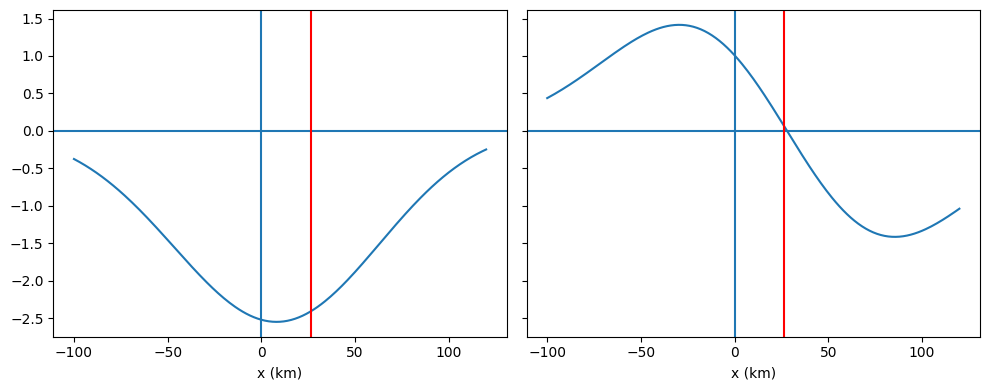

In [54]:
fig, axs = plt.subplots(1, 2, figsize=(10,4), sharey=True)




def find_root(x, y, degree=3):
    if x.size < degree + 1:
        return np.nan

    try:
        coeffs = np.polyfit(x, y, degree)
        roots = np.roots(coeffs)
    except Exception:
        return np.nan

    real_roots = roots[np.isreal(roots)].real
    if real_roots.size == 0:
        return np.nan

    mid_x = np.median(x)
    return real_roots[np.argmin(np.abs(real_roots - mid_x))]

# def tangent_at_root(x, y, root_x, degree=3):
#     if x.size < degree + 1 or not np.isfinite(root_x):
#         return np.nan, np.nan, np.nan

#     try:
#         coeffs = np.polyfit(x, y, degree)
#     except Exception:
#         return np.nan, np.nan, np.nan

#     p = np.poly1d(coeffs)
#     dp = np.polyder(p)

#     slope = dp(root_x)
#     intercept = p(root_x) - slope * root_x

#     y_fit = p(x)
#     ss_tot = np.sum((y - np.mean(y))**2)
#     ss_res = np.sum((y - y_fit)**2)
#     r2 = 1.0 if np.isclose(ss_tot, 0) else 1 - ss_res / ss_tot

#     return slope, intercept, r2

x_mask = (x >= -100) & (x <= 120)

x0_root = find_root(x[x_mask], v[x_mask, jc])

jc = 180
axs[0].plot(x[x_mask], u[x_mask, jc])
axs[0].axvline(0); axs[0].axhline(0)
axs[0].set_xlabel('x (km)')
axs[0].axvline(x0_root, color='r')

axs[1].plot(x[x_mask], v[x_mask, jc])
axs[1].axvline(0); axs[1].axhline(0)
axs[1].set_xlabel('x (km)')
axs[1].axvline(x0_root, color='r')

plt.tight_layout()

              0         1         2         3
A  6.265253e-01  0.029476 -0.000106 -0.000003
B  2.911105e-15 -0.073914  0.000026  0.000009
C -2.975682e-15  0.073914 -0.000026 -0.000009
D -6.265253e-01 -0.029476  0.000106  0.000003


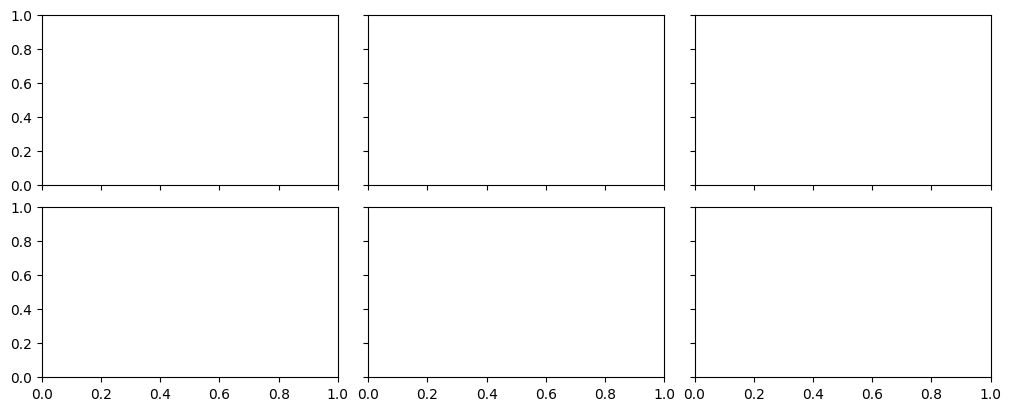

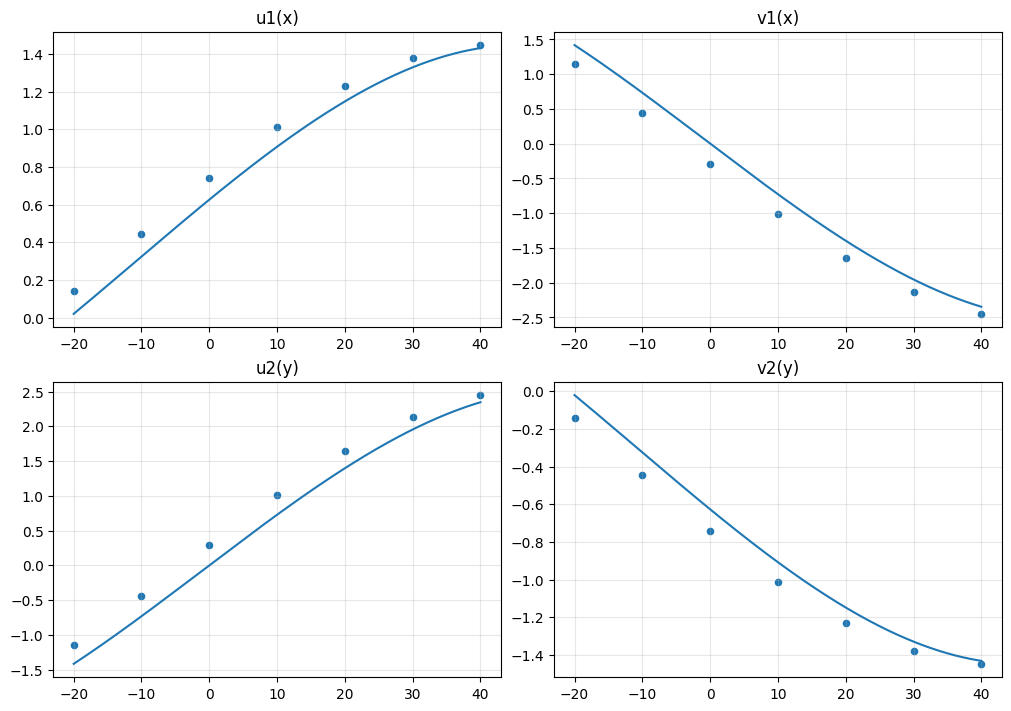

              0         1         2         3
A  1.465603e+00  0.027859 -0.000213 -0.000004
B -3.231505e-15 -0.069160 -0.000031  0.000008
C -2.899915e-15  0.069160 -0.000031 -0.000008
D  1.465603e+00 -0.027859 -0.000213  0.000004
              0         1         2             3
A -1.691059e+00  0.032984  0.000596  1.736862e-06
B  5.343805e-16 -0.081535 -0.000681  4.297767e-07
C -5.343805e-16  0.081535  0.000681 -4.297767e-07
D  1.691059e+00 -0.032984 -0.000596 -1.736862e-06
              0         1         2         3
A  6.264443e-01  0.029804 -0.000113 -0.000003
B -4.097499e-17 -0.074526  0.000034  0.000009
C  5.040793e-17  0.074526 -0.000034 -0.000009
D -6.264443e-01 -0.029804  0.000113  0.000003


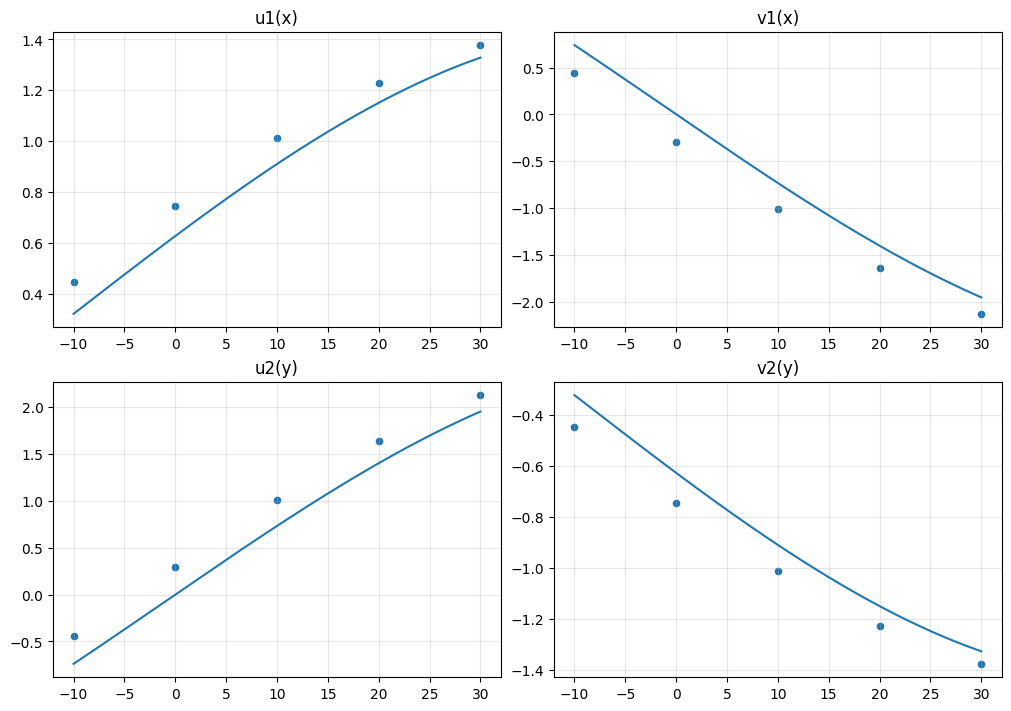

              0         1         2         3
A  6.265253e-01  0.029476 -0.000106 -0.000003
B  2.911105e-15 -0.073914  0.000026  0.000009
C -2.975682e-15  0.073914 -0.000026 -0.000009
D -6.265253e-01 -0.029476  0.000106  0.000003


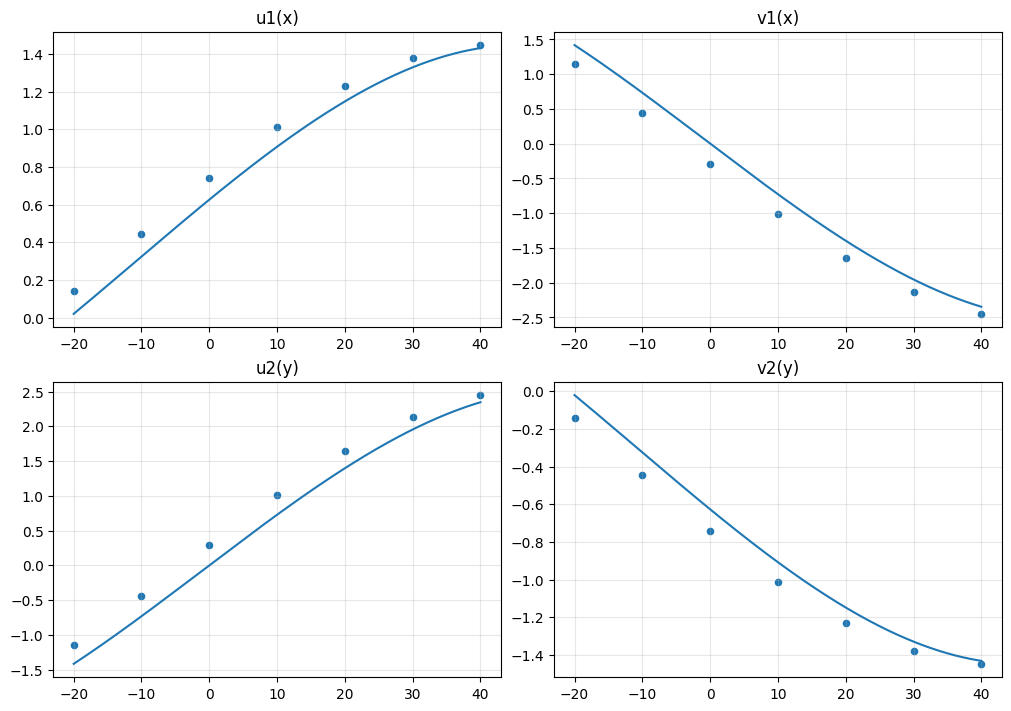

              0         1         2         3
A  6.260124e-01  0.029006 -0.000097 -0.000003
B -1.464907e-15 -0.073002  0.000016  0.000008
C  1.475853e-15  0.073002 -0.000016 -0.000008
D -6.260124e-01 -0.029006  0.000097  0.000003


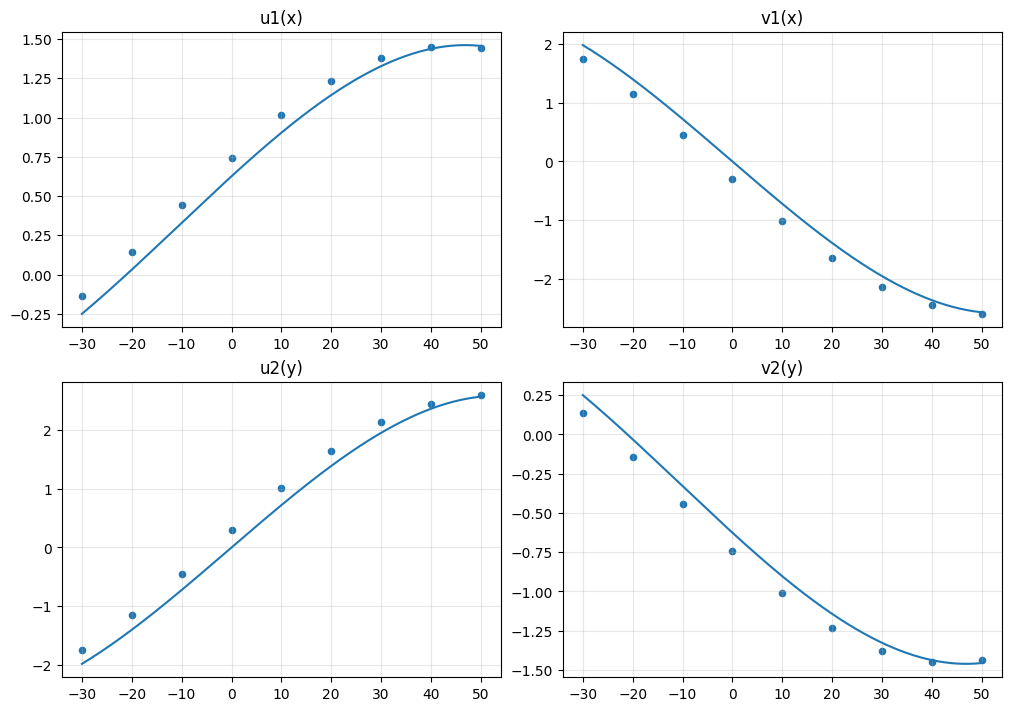

,xc,yc,w,q11,q12,q22,Rc,psi0,Omega
Control,0.000000,0.000000,-0.000151,1.091089,0.436436,1.091089,85.000000,2.500000e+02,-0.000069
P1,-5.198614,-5.198614,-0.000154,1.063087,-0.360768,1.063087,133545.272648,5.339935e+08,-0.000060
P2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
L1,-5.343426,-5.343426,-0.000181,1.004433,-0.094262,1.004433,508647.212331,8.489542e+09,-0.000066
L2,-5.198614,-5.198614,-0.000154,1.063087,-0.360768,1.063087,133545.272648,5.339935e+08,-0.000060
L3,-5.167768,-5.167768,-0.000146,1.089944,-0.433565,1.089944,109.781977,3.427394e+02,-0.000057


In [11]:
df_res = pd.DataFrame({'xc': [xc], 'yc': [yc], 'w': [w], 'q11': [q11], 'q12': [q12], 'q22': [q22],
                        'Rc': [Rc], 'psi0': [psi0], 'Omega': [Omega]})

nic, njc = 52, 52
r = 6

df_tests = pd.DataFrame({
    'nic': [nic, 45, 44, nic, nic, nic],
    'njc': [njc, 55, 44, njc, njc, njc],
    'r': [r, r, r, r-2, r, r+2]
}, index=['P1', 'P2', 'P3', 'L1', 'L2', 'L3'])

df_tests = df_tests*5

fig, axs = plt.subplots(2, 3, constrained_layout=True, figsize=(10, 4), sharey=True, sharex=True)
axs = axs.flatten()

dic_tests = {}
skip = 10
clrs = ['g', 'r', 'b']*2
for t, test in enumerate(df_tests.index):
    data = df_tests.loc[test]

    x1 = x[data.nic-data.r:data.nic+data.r+1:skip]
    y1 = np.array([y[data.njc]] * len(x1))

    u1 = u[data.nic-data.r:data.nic+data.r+1:skip, data.njc]
    v1 = v[data.nic-data.r:data.nic+data.r+1:skip, data.njc]

    y2 = y[data.njc-data.r:data.njc+data.r+1:skip]
    x2 = np.array([x[data.nic]] * len(y2))

    u2 = u[data.nic, data.njc-data.r:data.njc+data.r+1:skip]
    v2 = v[data.nic, data.njc-data.r:data.njc+data.r+1:skip]

    points1 = set(zip(x1, y1)); points2 = set(zip(x2, y2))
    common_points = points1 & points2
    # Remove duplicates from (x1, y1, u1, v1)
    mask = ~np.array([(x, y) in common_points for x, y in zip(x1, y1)])
    x1f = x1[mask]; y1f = y1[mask]; u1f = u1[mask]; v1f = v1[mask]
    # Concatenate with unaltered second set
    xi = np.concatenate([x1f, x2]); yi = np.concatenate([y1f, y2])
    ui = np.concatenate([u1f, u2]); vi = np.concatenate([v1f, v2])

    xc_dop, yc_dop, w_dop, Q_dop, Omega_dop = doppio(x1, y1, u1, v1, x2, y2, u2, v2, plot=True)#, plot=False,
                                                                     # use_A0=True, use_B0=True, use_C0=True, use_D0=True, use_D1=True)

    # xc_dop, yc_dop, w_dop, Q_dop, Omega_dop, df = doppio(x1, y1, u1, v1, x2, y2, u2, v2)
    # print(df)
                                                                    
    # print(param_finder(x1, y1, u1, v1, x2, y2, u2, v2, plot=True))

    df = psi_params(xc_dop, yc_dop, Q_dop, xi, yi, ui, vi)
    Rc_dop, psi0_dop, Omega_dop = out_core_param_fit(df.rho2, df.Qr, df.vt, Omega0=Omega_dop, 
                                     Rc_max=1e6, clr=clrs[t], ax=axs[t], plot=True)
    
    w_dop *= 1e-3
    Omega_dop *= 1e-3
    
    # dic_tests[test] = {'x1': x1, 'y1': y1, 'u1': u1, 'v1': v1,
    #                    'x2': x2, 'y2': y2, 'u2': u2, 'v2': v2,
    #                    'name': test}#, 'U1': U1, 'V1': V1, 'U2': U2, 'V2': V2}
    dic_tests[test] = {'x1': x1, 'y1': y1, 'u1': u1, 'v1': v1,
                       'x2': x2, 'y2': y2, 'u2': u2, 'v2': v2,
                       'name': test, 'U1': [np.nan]*len(x1), 'V1': [np.nan]*len(x1),
                       'U2': [np.nan]*len(y2), 'V2': [np.nan]*len(y2)}

    
    df_res.loc[len(df_res)] = {'xc': xc_dop, 'yc': yc_dop, 'w': w_dop,
                               'q11': Q_dop[0,0], 'q12': Q_dop[0,1], 'q22': Q_dop[1,1],
                               'Rc': Rc_dop, 'psi0': psi0_dop, 'Omega': Omega_dop}

for a, ax in enumerate(axs):
    # if a%2==0:
    ax.set_title('E'+df_tests.index[a])
    ax.set_xlabel(r'$\rho$ (km)')
    if a in [0, 3]:
        ax.set_ylabel(r'$|v_t^\star|$ (ms$^{-1}$)')
    else:
        ax.set_ylabel('')
    ax.axvline(Rc/np.sqrt(2), color='k', zorder=-1, alpha=.5)

df_res.index = ['Control'] + list(df_tests.index)
df_res


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


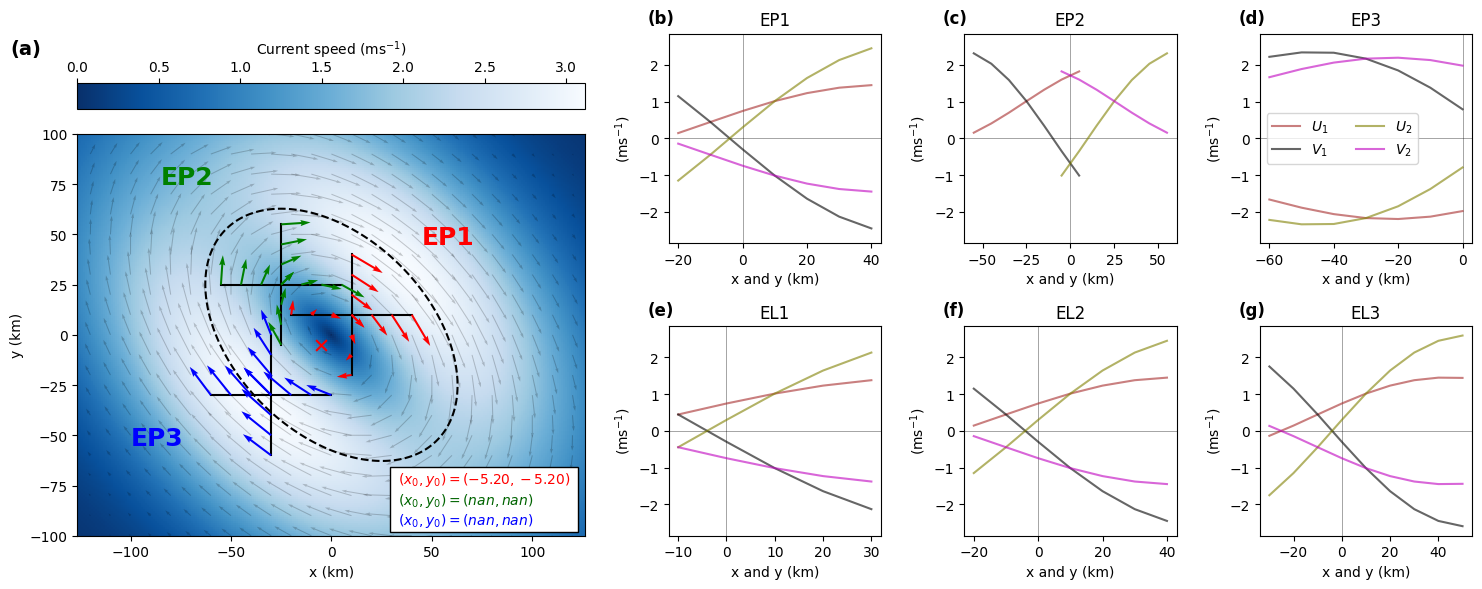

In [12]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize=(15, 6))
gs = gridspec.GridSpec(2, 5, figure=fig)

# Main panel takes first two columns
ax_main = fig.add_subplot(gs[:, :2])

cmap = 'Blues_r'
spacing, scale, width = 10, 40, 0.002

pc = ax_main.pcolor(x, y, np.hypot(u, v).T, cmap=cmap)
plt.colorbar(
    pc, ax=ax_main, orientation='horizontal',
    location='top', label='Current speed (ms$^{-1}$)'
)

ax_main.quiver(
    x[::spacing], y[::spacing],
    u[::spacing, ::spacing].T, v[::spacing, ::spacing].T,
    alpha=0.2, scale=scale, width=width
)

ax_main.contour(X, Y, rho2, levels=[Rc**2/2], colors='k', linestyles='--')

colours = ['r', 'g', 'b']
color = ['r', 'g', 'b']

i = 0
for dic in dic_tests.values():
    if 'P' in dic['name']:
        x1, y1, u1, v1, x2, y2, u2, v2 = (dic[k] for k in ['x1', 'y1', 'u1', 'v1', 'x2', 'y2', 'u2', 'v2'])
        data = df_res.loc[dic['name']]

        ax_main.plot(x1, y1, 'k', zorder=1)
        ax_main.plot(x2, y2, 'k', zorder=1)

        ax_main.quiver(x1, y1, u1, v1, scale=scale, width=width*2, color=colours[i])
        ax_main.quiver(x2, y2, u2, v2, scale=scale, width=width*2, color=colours[i])
        ax_main.scatter(
            data.xc, data.yc, marker='x', s=60, color=colours[i],
            zorder=10-extract_number(dic['name'])
        )

        dx_ell, dy_ell = X - data.xc, Y - data.yc
        rho2_ell = data.q11*dx_ell**2 + 2*data.q12*dx_ell*dy_ell + data.q22*dy_ell**2
        ax_main.contour(
            X, Y, rho2_ell, levels=[data.Rc**2/2],
            colors=colours[i], linestyles='--'
        )

        ax_main.text(
            33, -74 - 10*i,
            fr'$(x_0,y_0)=({data.xc:.2f},{data.yc:.2f})$',
            color='darkgreen' if '2' in dic['name'] else colours[i],
            zorder=11
        )
        i += 1

x_pos, y_pos = 0.80, 0.09
box_width = 0.37
box_height = 0.16
rect = Rectangle(
    (x_pos - box_width / 2, y_pos - box_height / 2),
    box_width, box_height,
    transform=ax_main.transAxes,
    facecolor='white', edgecolor='black', zorder=10
)
ax_main.add_patch(rect)

ax_main.text(-160, 140, '(a)', fontsize=14, fontweight='bold')
ax_main.axis('equal')
ax_main.set_xlim(-100, 100)
ax_main.set_ylim(-100, 100)
ax_main.set_xlabel('x (km)')
ax_main.set_ylabel('y (km)')

axs = []
tags = ['(b)','(c)', '(d)', '(e)', '(f)','(g)']

for d, dic in enumerate(dic_tests.values()):
    x1, y1, u1, v1, x2, y2, u2, v2 = (dic[k] for k in ['x1', 'y1', 'u1', 'v1', 'x2', 'y2', 'u2', 'v2'])
    U1, V1, U2, V2 = (dic[k] for k in ['U1', 'V1', 'U2', 'V2'])
    data = df_res.loc[dic['name']]

    # Put small panels in cols 2, 3, 4
    ax2 = fig.add_subplot(gs[d // 3, 2 + (d % 3)])

    ax2.plot(x1, u1, color='brown', label=r'$U_1$', alpha=.6)
    ax2.plot(x1, U1, color='brown', alpha=.2, marker='*')
    ax2.plot(x1, v1, 'k', label=r'$V_1$', alpha=.6)
    ax2.plot(x1, V1, 'k', alpha=.2, marker='*')
    ax2.plot(y2, u2, color='olive', label=r'$U_2$', alpha=.6)
    ax2.plot(y2, U2, color='olive', alpha=.2, marker='*')
    ax2.plot(y2, v2, 'm', label=r'$V_2$', alpha=.6)
    ax2.plot(y2, V2, 'm', alpha=.2, marker='*')

    ax2.axhline(y=0, color='k', zorder=-1, linewidth=.5, alpha=.5)
    ax2.axvline(x=0, color='k', zorder=-1, linewidth=.5, alpha=.5)
    ax2.set_ylabel('(ms$^{-1}$)')
    ax2.set_xlabel('x and y (km)')
    ax2.set_title('E' + dic['name'])

    if dic['name']=='P3':
        ax2.legend(loc='center left', ncol=2)

    axs.append(ax2)

    ax2.text(-0.1, 1.05, tags[d], fontsize=12, fontweight='bold', transform=ax2.transAxes)

ymin = min(ax.get_ylim()[0] for ax in axs)
ymax = max(ax.get_ylim()[1] for ax in axs)
for ax in axs:
    ax.set_ylim(ymin, ymax)

ax_main.text(45, 45, 'EP1', color=color[0], zorder=3, fontsize=18, fontweight='bold')
ax_main.text(-85, 75, 'EP2', color=color[1], zorder=3, fontsize=18, fontweight='bold')
ax_main.text(-100, -55, 'EP3', color=color[2], zorder=3, fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()


In [13]:
df_paper = df_res.copy()
df_paper['alpha'] = [axis_ratio_from_Q(np.array([[q11, q12], [q12, q22]])) for (q11, q12, q22) in zip(df_paper.q11, df_paper.q12, df_paper.q22)]
df_paper = df_paper.drop(columns=['q11', 'q12', 'q22'])
df_paper


,xc,yc,w,Rc,psi0,Omega,alpha
Control,0.000000,0.000000,-0.000151,85.000000,2.500000e+02,-0.000069,1.527525
P1,-5.198614,-5.198614,-0.000154,133545.272648,5.339935e+08,-0.000060,1.423855
P2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
L1,-5.343426,-5.343426,-0.000181,508647.212331,8.489542e+09,-0.000066,1.098694
L2,-5.198614,-5.198614,-0.000154,133545.272648,5.339935e+08,-0.000060,1.423855
L3,-5.167768,-5.167768,-0.000146,109.781977,3.427394e+02,-0.000057,1.523509


In [14]:
df_err = (df_paper - df_paper.iloc[0]).abs().iloc[1:]
df_err.index = ['EP1 Err', 'EP2 Err', 'EP3 Err',
                'EL1 Err', 'EL2 Err', 'EL3 Err']
df_err


,xc,yc,w,Rc,psi0,Omega,alpha
EP1 Err,5.198614,5.198614,0.000003,133460.272648,5.339932e+08,0.000009,0.103670
EP2 Err,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EP3 Err,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EL1 Err,5.343426,5.343426,0.000030,508562.212331,8.489542e+09,0.000004,0.428831
EL2 Err,5.198614,5.198614,0.000003,133460.272648,5.339932e+08,0.000009,0.103670
EL3 Err,5.167768,5.167768,0.000005,24.781977,9.273939e+01,0.000012,0.004016


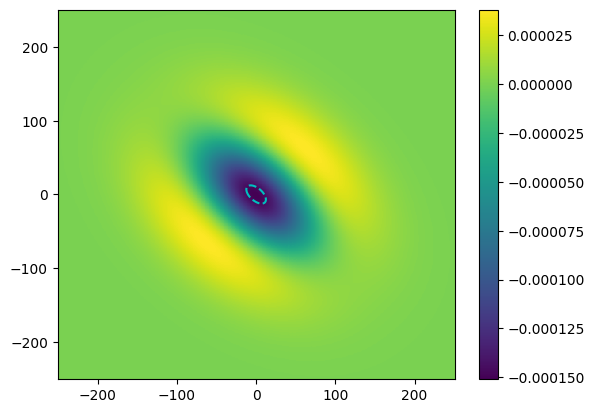

In [15]:
dx = (X[1,0] - X[0,0])*1e3
dy = (Y[0,1] - Y[0,0])*1e3

dv_dx = np.gradient(v, dx, axis=0)
du_dy = np.gradient(u, dy, axis=1)

zeta = dv_dx - du_dy
plt.pcolor(X, Y, zeta)
plt.colorbar()
clrs =['r', 'm', 'b', 'w', 'orange', 'y', 'c']
for i, clr in enumerate(clrs):
    plt.contour(X, Y, zeta, levels=[df_res.iloc[i].w], colors=clr) 
    

In [16]:
# dx = (X[1,0] - X[0,0])*1e3
# dy = (Y[0,1] - Y[0,0])*1e3

# dv_dx = np.gradient(v, dx, axis=0)
# du_dy = np.gradient(u, dy, axis=1)

# zeta = dv_dx - du_dy
# plt.pcolor(X, Y, zeta)
# plt.colorbar()
# plt.contour(X, Y, zeta, levels=[df_res.iloc[0].w], colors='r') 
# # plt.contour(X, Y, zeta, levels=[-0.07391396167122072*1e-3], colors='r') 


### Pres Plots

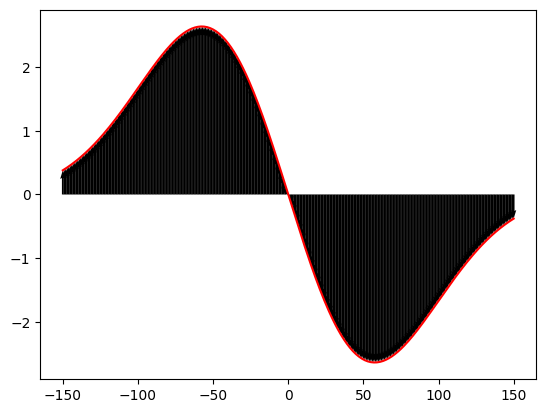

In [17]:
data = pd.DataFrame({'nic': [50], 'njc': [50], 'r': [30]}).iloc[0]*5

x1 = x[data.nic-data.r:data.nic+data.r+1]
y1 = np.array([y[data.njc]] * len(x1))

u1 = u[data.nic-data.r:data.nic+data.r+1, data.njc]
v1 = v[data.nic-data.r:data.nic+data.r+1, data.njc]


plt.quiver(x1, [0]*len(x1), [0]*len(v1), v1, scale_units='xy', scale=1)
plt.plot(x1, v1, color='r') 



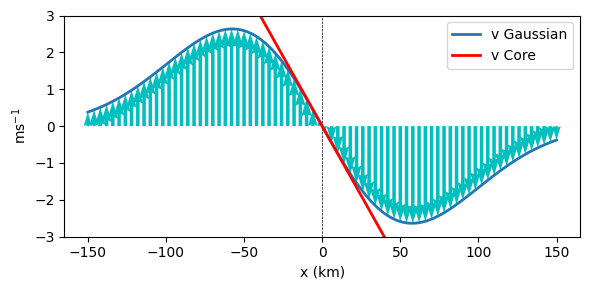

In [18]:
plt.figure(figsize=(6,3))
plt.axvline(x=0, color='k', linewidth=.5, linestyle='--')
plt.plot(x1, v1, linewidth=2, label='v Gaussian')
spac = 4
plt.quiver(x1[::spac], [0]*len(x1[::spac]), [0]*len(v1[::spac]), v1[::spac], scale_units='xy', scale=1, color='c')

vcore = 2*A*q11*(x1-xc) + 2*A*q12*(y1-yc)
plt.plot(x1, vcore, 'r-', linewidth=2, label='v Core')

plt.legend()
plt.xlabel(r'x (km)')
plt.ylabel(r'ms$^{-1}$')
plt.ylim(-3, 3)
plt.tight_layout()


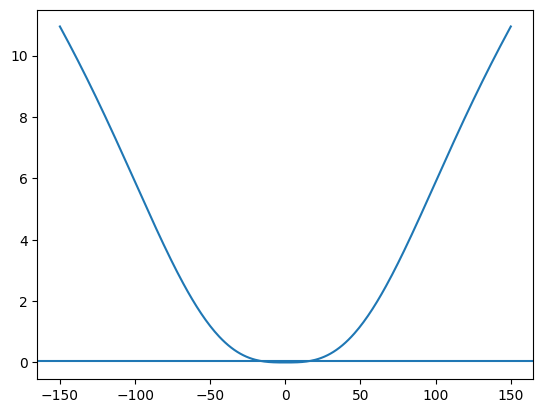

In [19]:
plt.plot(x1, np.abs(vcore-v1))
plt.axhline(y=.05)


In [20]:
def deform_eddy(Q11=1, Q12=0, Q22=1):
    width=500
    x = np.linspace(-width // 2, width // 2, 501)
    y = np.linspace(-width // 2, width // 2, 501)
    X, Y = np.meshgrid(x, y, indexing='ij')
    
    xc, yc = 0.0, 0.0

    psi0 = 250
    Rc = 85.0
    A = - psi0 / Rc**2 
    
    # rescale Q to have unit determinant
    Q, _ = unit_det(Q=np.array([[Q11, Q12], [Q12, Q22]]))
    q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]
    
    dx, dy = X - xc, Y - yc
    rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
    Qr2 = (q11*dx + q12*dy)**2 + (q12*dx + q22*dy)**2 # ||Qr||
    psi = psi0 * np.exp( - rho2 / Rc**2 )
    u =   psi0 * np.exp( - rho2 / Rc**2 ) * ( 2*q12*dx + 2*q22*dy ) / Rc**2
    v = - psi0 * np.exp( - rho2 / Rc**2 ) * ( 2*q11*dx + 2*q12*dy ) / Rc**2

    nic, njc, r = 260, 260, 30
    skip = 10
    x1 = x[nic-r:nic+r+1:skip]
    y1 = np.array([y[njc]] * len(x1))

    u1 = u[nic-r:nic+r+1:skip, njc]
    v1 = v[nic-r:nic+r+1:skip, njc]

    y2 = y[njc-r:njc+r+1:skip]
    x2 = np.array([x[nic]] * len(y2))

    u2 = u[nic, njc-r:njc+r+1:skip]
    v2 = v[nic, njc-r:njc+r+1:skip]

    xc_dop, yc_dop, w_dop, Q_dop, Rc_dop, psi0_dop, A_dop = dopioe(x1, y1, u1, v1, x2, y2, u2, v2, plot_flag=False)
    w_dop *= 1e-6
    
    return xc_dop, yc_dop, w_dop, Q_dop, Rc_dop, psi0_dop, A_dop, q11, q12, q22


df_deform_tests = pd.DataFrame({'xc': [xc], 'yc': [yc], 'w': [2*A*(q11+q22)*1e-3], 'q11': [q11], 'q12': [q12], 'q22': [q22],
                        'Rc': [Rc], 'psi0': [psi0], 'A': [A], 'Q11': np.nan, 'Q12': np.nan, 'Q22': np.nan})

for Q12 in np.arange(0.0, .8 + 0.05, 0.05):
    xc_dop, yc_dop, w_dop, Q_dop, Rc_dop, psi0_dop, A_dop, Q11, Q12, Q22 = deform_eddy(Q12=Q12)
    df_deform_tests.loc[len(df_deform_tests)] = {'xc': xc_dop, 'yc': yc_dop, 'w': w_dop, 'q11': Q_dop[0,0], 'q12': Q_dop[1,0], 'q22': Q_dop[1,1],
                        'Rc': Rc_dop, 'psi0': psi0_dop, 'A': A_dop, 'Q11': Q11, 'Q12': Q12, 'Q22': Q22}
df_deform_tests = df_deform_tests.iloc[1:]
df_deform_tests




,xc,yc,w,q11,q12,q22,Rc,psi0,A,Q11,Q12,Q22
1,-0.017653,-0.017653,-1.383016e-07,1.000001,-0.001295,1.000001,85.199209,250.979372,-0.034575,1.000000,0.000000,1.000000
2,-0.019628,-0.019628,-1.384622e-07,1.001187,0.048746,1.001187,85.207822,251.023788,-0.034575,1.001252,0.050063,1.001252
3,-0.021669,-0.021669,-1.389735e-07,1.004905,0.099163,1.004905,85.212516,251.046320,-0.034574,1.005038,0.100504,1.005038
4,-0.023802,-0.023802,-1.398474e-07,1.011239,0.150348,1.011239,85.213337,251.047460,-0.034573,1.011443,0.151717,1.011443
5,-0.026056,-0.026056,-1.411051e-07,1.020341,0.202723,1.020341,85.210378,251.028000,-0.034573,1.020621,0.204124,1.020621
6,-0.028466,-0.028466,-1.427778e-07,1.032437,0.256762,1.032437,85.203791,250.989050,-0.034573,1.032796,0.258199,1.032796
7,-0.031074,-0.031074,-1.449093e-07,1.047842,0.313007,1.047842,85.193807,250.932136,-0.034573,1.048285,0.314485,1.048285
8,-0.033936,-0.033936,-1.475593e-07,1.066988,0.372108,1.066988,85.180784,250.859384,-0.034574,1.067521,0.373632,1.067521
9,-0.037118,-0.037118,-1.508087e-07,1.090459,0.434858,1.090459,85.165271,250.773787,-0.034575,1.091089,0.436436,1.091089
10,-0.040713,-0.040713,-1.547668e-07,1.119049,0.502265,1.119049,85.148099,250.679559,-0.034576,1.119785,0.503903,1.119785


In [21]:
df_deform_tests['Err'] = np.hypot(df_deform_tests.xc, df_deform_tests.yc)
# Aspect Ratio
ARs = []
for k in range(len(df_deform_tests)):
    data = df_deform_tests.iloc[k]
    ARs.append(ellipse_aspect_ratio(data.Q11, data.Q12, data.Q22))
df_deform_tests['AR'] = ARs
df_deform_tests


,xc,yc,w,q11,q12,q22,Rc,psi0,A,Q11,Q12,Q22,Err,AR
1,-0.017653,-0.017653,-1.383016e-07,1.000001,-0.001295,1.000001,85.199209,250.979372,-0.034575,1.000000,0.000000,1.000000,0.024965,1.000000
2,-0.019628,-0.019628,-1.384622e-07,1.001187,0.048746,1.001187,85.207822,251.023788,-0.034575,1.001252,0.050063,1.001252,0.027759,1.051315
3,-0.021669,-0.021669,-1.389735e-07,1.004905,0.099163,1.004905,85.212516,251.046320,-0.034574,1.005038,0.100504,1.005038,0.030645,1.105542
4,-0.023802,-0.023802,-1.398474e-07,1.011239,0.150348,1.011239,85.213337,251.047460,-0.034573,1.011443,0.151717,1.011443,0.033661,1.163160
5,-0.026056,-0.026056,-1.411051e-07,1.020341,0.202723,1.020341,85.210378,251.028000,-0.034573,1.020621,0.204124,1.020621,0.036848,1.224745
6,-0.028466,-0.028466,-1.427778e-07,1.032437,0.256762,1.032437,85.203791,250.989050,-0.034573,1.032796,0.258199,1.032796,0.040256,1.290994
7,-0.031074,-0.031074,-1.449093e-07,1.047842,0.313007,1.047842,85.193807,250.932136,-0.034573,1.048285,0.314485,1.048285,0.043946,1.362770
8,-0.033936,-0.033936,-1.475593e-07,1.066988,0.372108,1.066988,85.180784,250.859384,-0.034574,1.067521,0.373632,1.067521,0.047992,1.441153
9,-0.037118,-0.037118,-1.508087e-07,1.090459,0.434858,1.090459,85.165271,250.773787,-0.034575,1.091089,0.436436,1.091089,0.052493,1.527525
10,-0.040713,-0.040713,-1.547668e-07,1.119049,0.502265,1.119049,85.148099,250.679559,-0.034576,1.119785,0.503903,1.119785,0.057577,1.623688


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


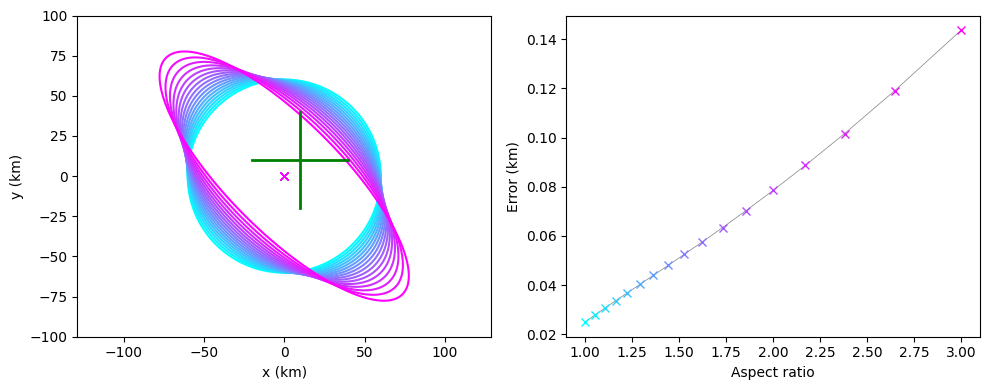

In [22]:
fig, axs = plt.subplots(1, 2, figsize=(10,4))

N = len(df_deform_tests)
cmap = plt.cm.cool
cols = cmap(np.linspace(0, 1, N))

# ------------------ RIGHT panel (was left) ------------------
axs[1].plot(df_deform_tests.AR, df_deform_tests.Err, lw=.5, color='k', alpha=.5)
for i, (ar, err) in enumerate(zip(df_deform_tests.AR, df_deform_tests.Err)):
    axs[1].plot(ar, err, marker='x', color=cols[i])

axs[1].set_xlabel('Aspect ratio')
axs[1].set_ylabel('Error (km)')

# ------------------ Grid ------------------
width = 500
x = np.linspace(-width // 2, width // 2, 501)
y = np.linspace(-width // 2, width // 2, 501)
X, Y = np.meshgrid(x, y, indexing='ij')

# ------------------ LEFT panel (was right) ------------------
for i, (q11, q12, q22) in enumerate(zip(df_deform_tests.Q11,
                                      df_deform_tests.Q12,
                                      df_deform_tests.Q22)):
    rho2_ = q11*X**2 + 2*q12*X*Y + q22*Y**2

    axs[0].contour(
        X, Y, rho2_,
        levels=[Rc**2/2],
        colors=[cols[i]],
        linewidths=1.5
    )

for i, (xc_, yc_) in enumerate(zip(df_deform_tests.xc, df_deform_tests.yc)):
    axs[0].plot(xc_, yc_, marker='x', color=cols[i])

# reference transect
nic_, njc_, r_ = 260, 260, 30
skip = 10
x1 = x[nic_-r_:nic_+r_+1:skip]
y1 = np.array([y[njc_]] * len(x1))
y2 = y[njc_-r_:njc_+r_+1:skip]
x2 = np.array([x[nic_]] * len(y2))
axs[0].plot(x1, y1, color='g', lw=2)
axs[0].plot(x2, y2, color='g', lw=2)

axs[0].axis('equal')
axs[0].set_xlim(-100, 100)
axs[0].set_ylim(-100, 100)
axs[0].set_xlabel('x (km)'); axs[0].set_ylabel('y (km)')

plt.tight_layout()


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


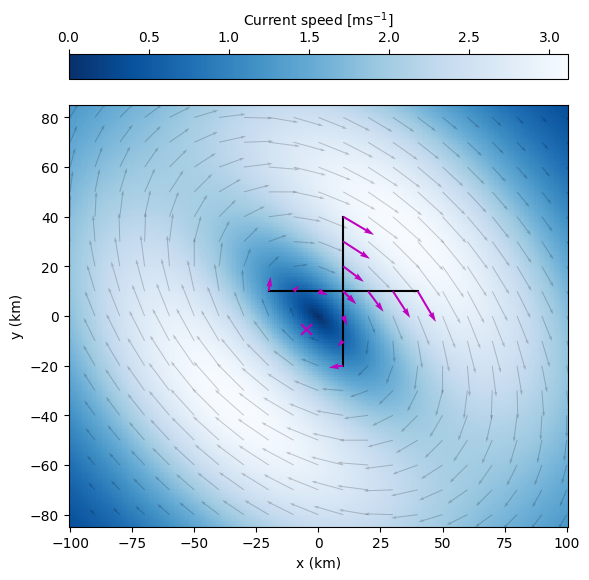

In [23]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

fig, ax_main = plt.subplots(figsize=(6, 6))

cmap = 'Blues_r'
spacing, scale, width = 2*5, 40, 0.002 #0.004
pc = ax_main.pcolor(x, y, np.hypot(u, v).T, cmap=cmap)
plt.colorbar(pc, ax=ax_main, orientation='horizontal', location='top', label='Current speed [ms$^{-1}$]')
ax_main.quiver(x[::spacing], y[::spacing], u[::spacing, ::spacing].T, v[::spacing, ::spacing].T, 
               alpha=0.2, scale=scale, width=width)

# ax_main.contour(X, Y, rho2, levels=[Rc**2/2],
#                      colors='k', linestyles='--')

colours = ['m', 'g', 'b'] # limegreen
color = ['m', 'g', 'b']

i = 0
scales = [40, 58, 65]
for dic in dic_tests.values():
    if dic['name'] == 'P1':

        x1, y1, u1, v1, x2, y2, u2, v2 = (dic[k] for k in ['x1', 'y1', 'u1', 'v1', 'x2', 'y2', 'u2', 'v2'])
        data = df_res.loc[dic['name']]
 
        ax_main.plot(x1, y1, 'k', zorder=1)
        ax_main.plot(x2, y2, 'k', zorder=1)

        ax_main.quiver(x1, y1, u1, v1, scale=scale, width=width*2, color=colours[i])
        ax_main.quiver(x2, y2, u2, v2, scale=scale, width=width*2, color=colours[i])
        ax_main.scatter(data.xc, data.yc, marker='x', s=60, color=colours[i], zorder=10-extract_number(dic['name']))

        dx_ell, dy_ell = X - data.xc, Y - data.yc
        rho2_ell = data.q11*dx_ell**2 + 2*data.q12*dx_ell*dy_ell + data.q22*dy_ell**2
        ax_main.contour(X, Y, rho2_ell, levels=[data.Rc**2/2], colors=colours[i])

        i += 1

ax_main.axis('equal')
ax_main.set_xlim(-80, 80)
ax_main.set_ylim(-80, 80)
ax_main.set_xlabel('x (km)')
ax_main.set_ylabel('y (km)')

plt.tight_layout()
plt.show()


#### LATTE

In [24]:
df_tests

,nic,njc,r
P1,260,260,30
P2,225,275,30
P3,220,220,30
L1,260,260,20
L2,260,260,30
L3,260,260,40


In [25]:
df_latte_res = df_res.copy()
df_latte_res['Method'] = 'doppio'

for t, test in enumerate(df_tests.index):
    data = df_tests.loc[test]

    x1 = x[data.nic-data.r:data.nic+data.r+1:skip]
    y1 = np.array([y[data.njc]] * len(x1))

    u1 = u[data.nic-data.r:data.nic+data.r+1:skip, data.njc]
    v1 = v[data.nic-data.r:data.nic+data.r+1:skip, data.njc]

    y2 = y[data.njc-data.r:data.njc+data.r+1:skip]
    x2 = np.array([x[data.nic]] * len(y2))

    u2 = u[data.nic, data.njc-data.r:data.njc+data.r+1:skip]
    v2 = v[data.nic, data.njc-data.r:data.njc+data.r+1:skip]

    points1 = set(zip(x1, y1)); points2 = set(zip(x2, y2))
    common_points = points1 & points2
    # Remove duplicates from (x1, y1, u1, v1)
    mask = ~np.array([(x, y) in common_points for x, y in zip(x1, y1)])
    x1f = x1[mask]; y1f = y1[mask]; u1f = u1[mask]; v1f = v1[mask]
    # Concatenate with unaltered second set
    xi = np.concatenate([x1f, x2]); yi = np.concatenate([y1f, y2])
    ui = np.concatenate([u1f, u2]); vi = np.concatenate([v1f, v2])

    xc_lat, yc_lat, w_lat, Q_lat, Rc_lat, psi0_lat, A_lat = espra(xi, yi, ui, vi, plot_flag=False)
    w_lat *= 1e-3
    A_lat *= 1e-3
    
    df = psi_params(xc_dop, yc_dop, Q_dop, xi, yi, ui, vi)
    
    df_latte_res.loc[len(df_latte_res)] = {'xc': xc_lat, 'yc': yc_lat, 'w': w_lat,
                               'q11': Q_lat[0,0], 'q12': Q_lat[0,1], 'q22': Q_lat[1,1],
                               'Rc': Rc_lat, 'psi0': psi0_lat, 'Omega': 2*A_lat, 'Method': 'latte'}
df_latte_res.index = list(df_latte_res.index[:7]) + ['P1', 'P2', 'P3', 'L1', 'L2', 'L3']

df_latte_res['alpha'] = [axis_ratio_from_Q(np.array([[q11, q12], [q12, q22]])) for (q11, q12, q22) in zip(df_latte_res.q11, df_latte_res.q12, df_latte_res.q22)]
df_latte_res = df_latte_res.drop(columns=['q11', 'q12', 'q22'])


df_latte_res


,xc,yc,w,Rc,psi0,Omega,Method,alpha
Control,0.000000,0.000000,-0.000151,85.000000,2.500000e+02,-0.000069,doppio,1.527525
P1,-5.198614,-5.198614,-0.000154,133545.272648,5.339935e+08,-0.000060,doppio,1.423855
P2,NaN,NaN,NaN,NaN,NaN,NaN,doppio,NaN
P3,NaN,NaN,NaN,NaN,NaN,NaN,doppio,NaN
L1,-5.343426,-5.343426,-0.000181,508647.212331,8.489542e+09,-0.000066,doppio,1.098694
L2,-5.198614,-5.198614,-0.000154,133545.272648,5.339935e+08,-0.000060,doppio,1.423855
L3,-5.167768,-5.167768,-0.000146,109.781977,3.427394e+02,-0.000057,doppio,1.523509
P1,-0.359387,-0.359387,-0.000148,89.232516,2.752100e+02,-0.000069,latte,1.461784
P2,7.282728,-7.282728,-0.000137,106.548671,3.369150e+02,-0.000059,latte,1.735671
P3,75.178450,75.178451,-0.000055,370.115185,1.819125e+03,-0.000027,latte,1.269722


In [26]:
vars_ = ["xc","yc","w","Rc","psi0","alpha","Omega"]

# split methods
df_dop = df_latte_res[df_latte_res.Method=="doppio"]
df_lat = df_latte_res[df_latte_res.Method=="latte"]

# control values (same for both)
ctrl = df_dop.loc["Control", vars_]

rows = []

for test in df_lat.index:
    
    if test == "Control":
        continue
    
    eps = (
        np.abs(df_lat.loc[test, vars_] - ctrl) -
        np.abs(df_dop.loc[test, vars_] - ctrl)
    ) / np.abs(df_lat.loc[test, vars_] - ctrl) * 100
    
    rows.append(eps)

df_pct = pd.DataFrame(rows, index=df_lat.index, columns=vars_)
df_pct


,xc,yc,w,Rc,psi0,alpha,Omega
P1,-1346.522999,-1346.522255,-15.961497,-3.153114e+06,-2.118184e+09,-57.693235,-11984.284709
P2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
L1,-797.603238,-797.603198,-261.918015,-2.899066e+06,-8.512304e+09,-550.912144,-33.378156
L2,-1346.522999,-1346.522255,-15.961497,-3.153114e+06,-2.118184e+09,-57.693235,-11984.284709
L3,-7256.124957,-7256.159441,-1025.172439,-1.648767e+03,-6.749356e+02,93.874681,-1192.316972
